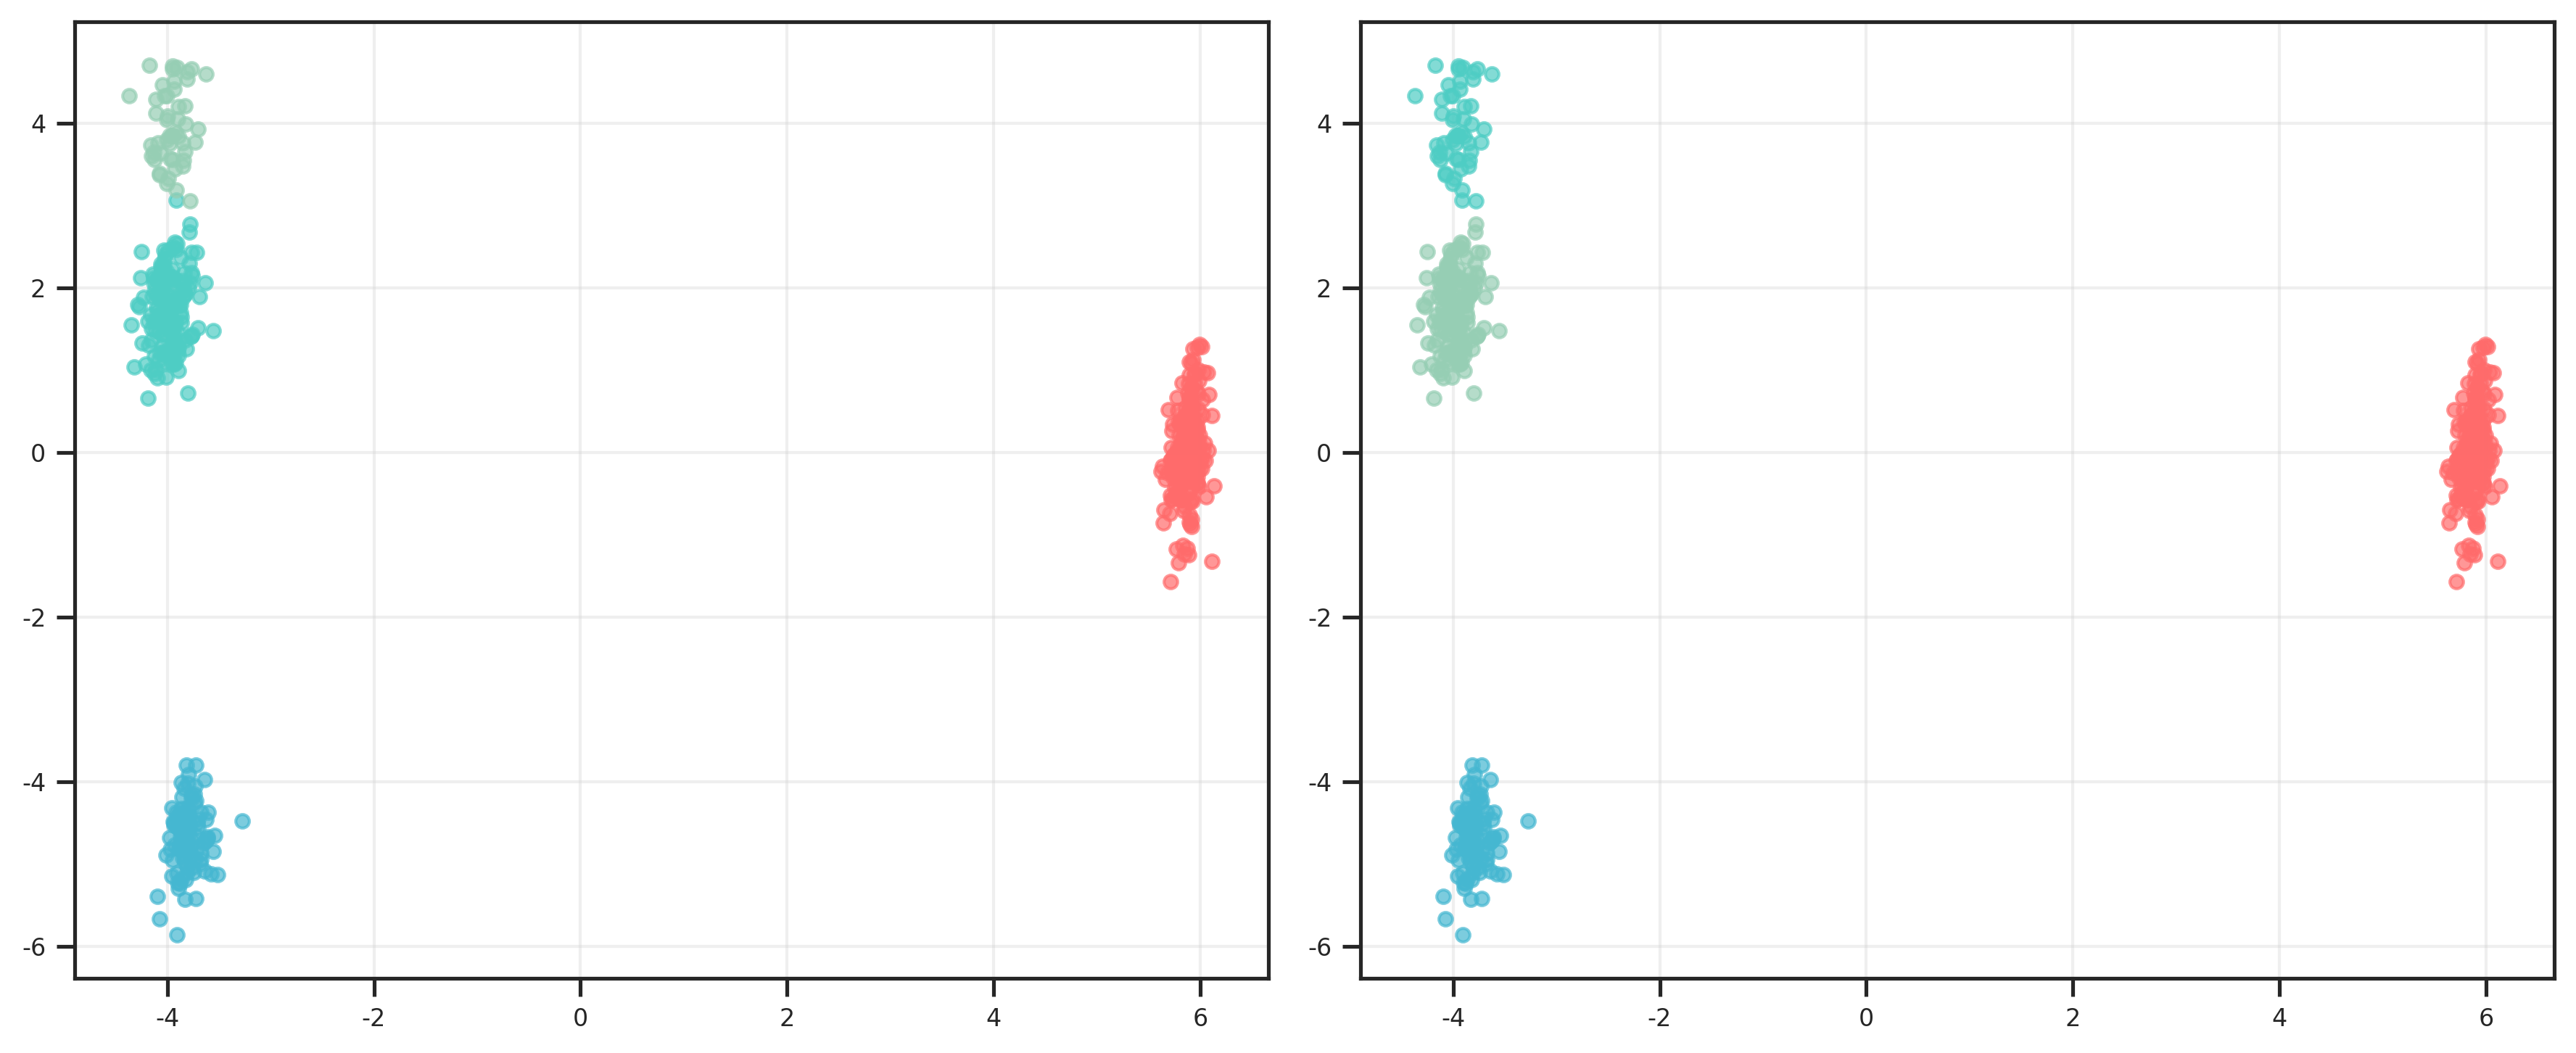

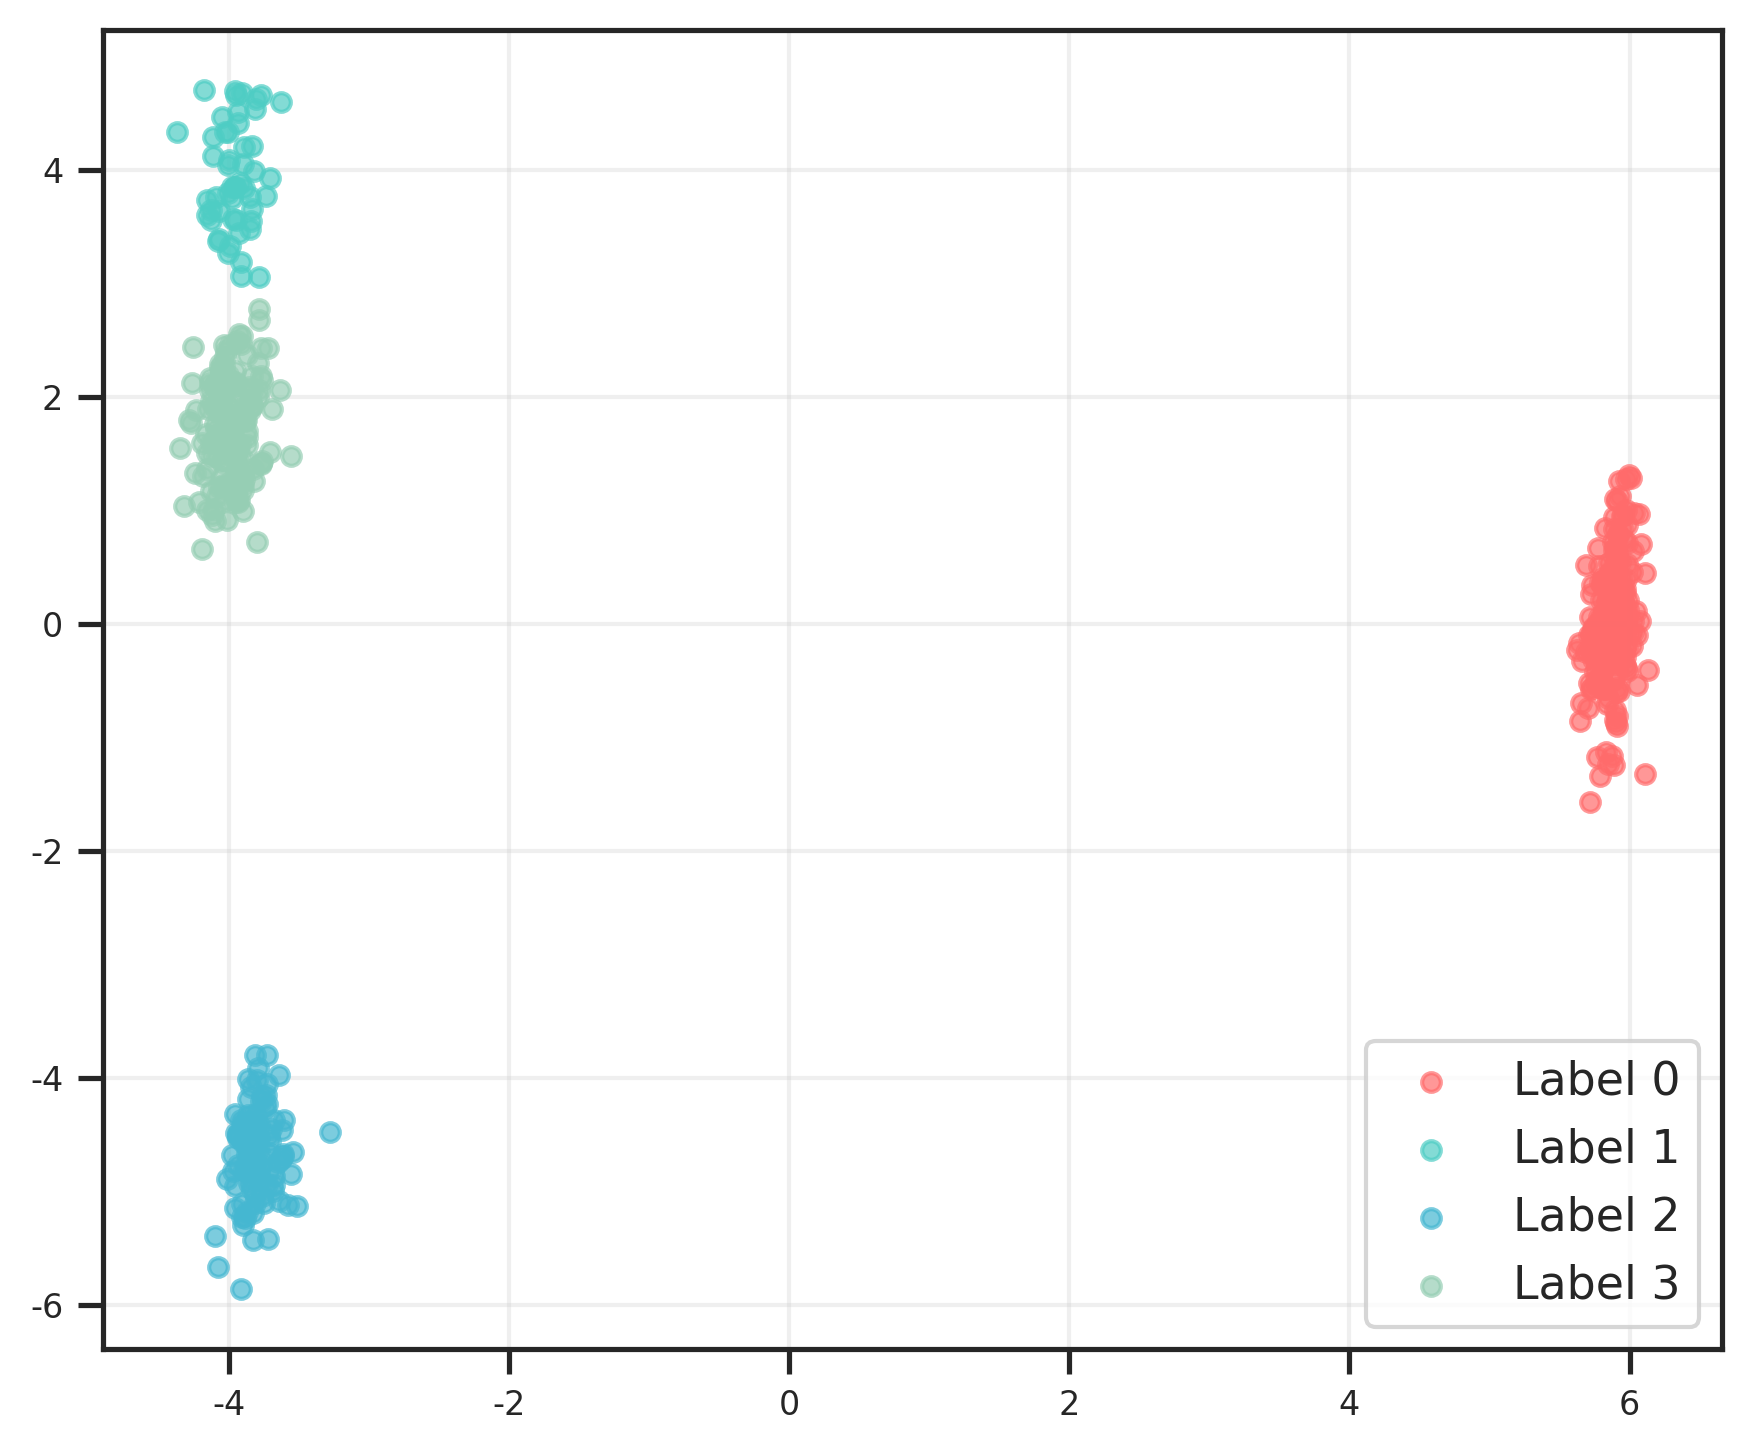

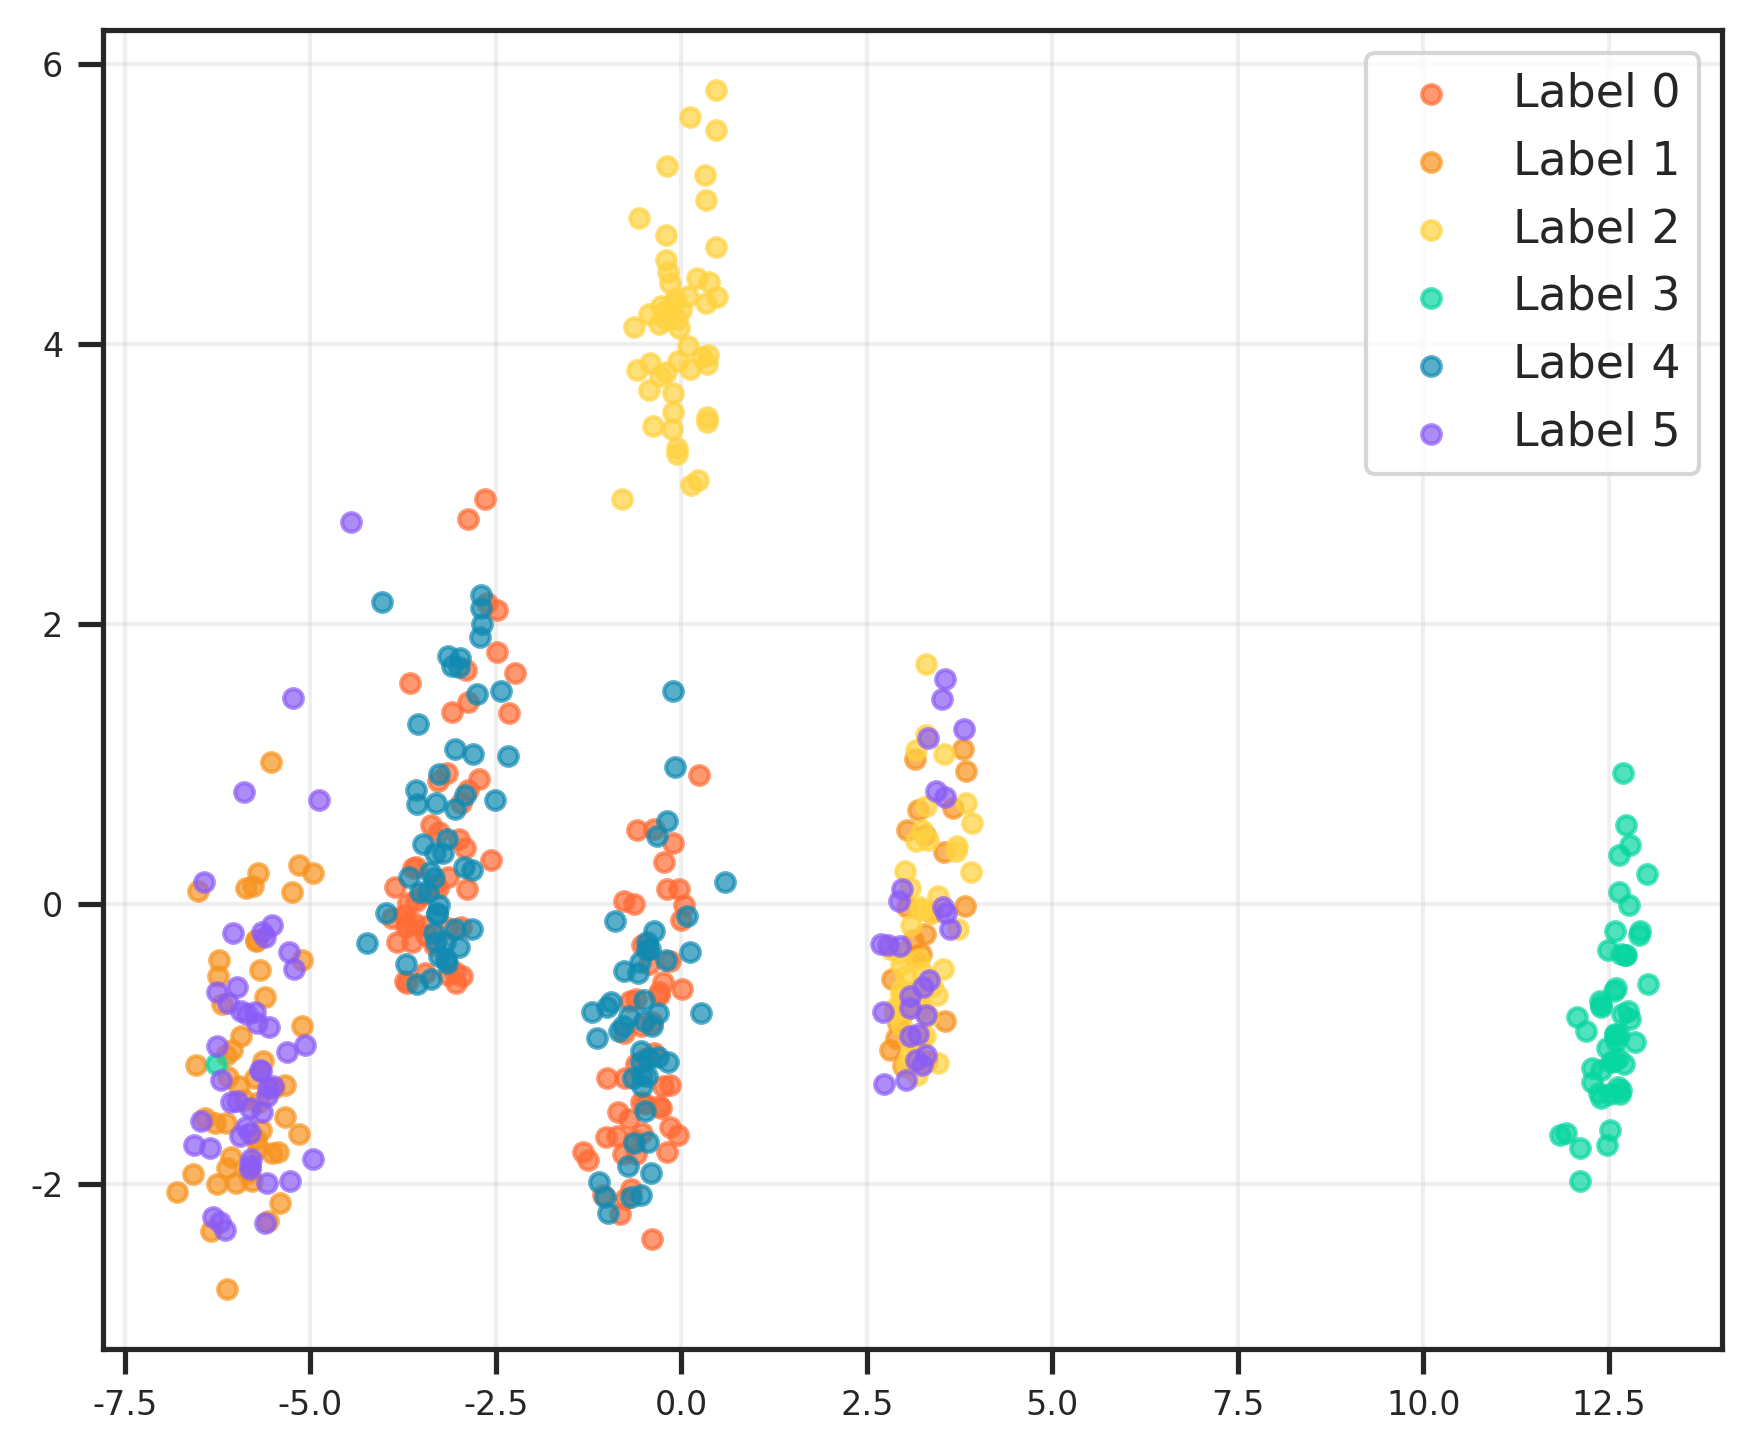

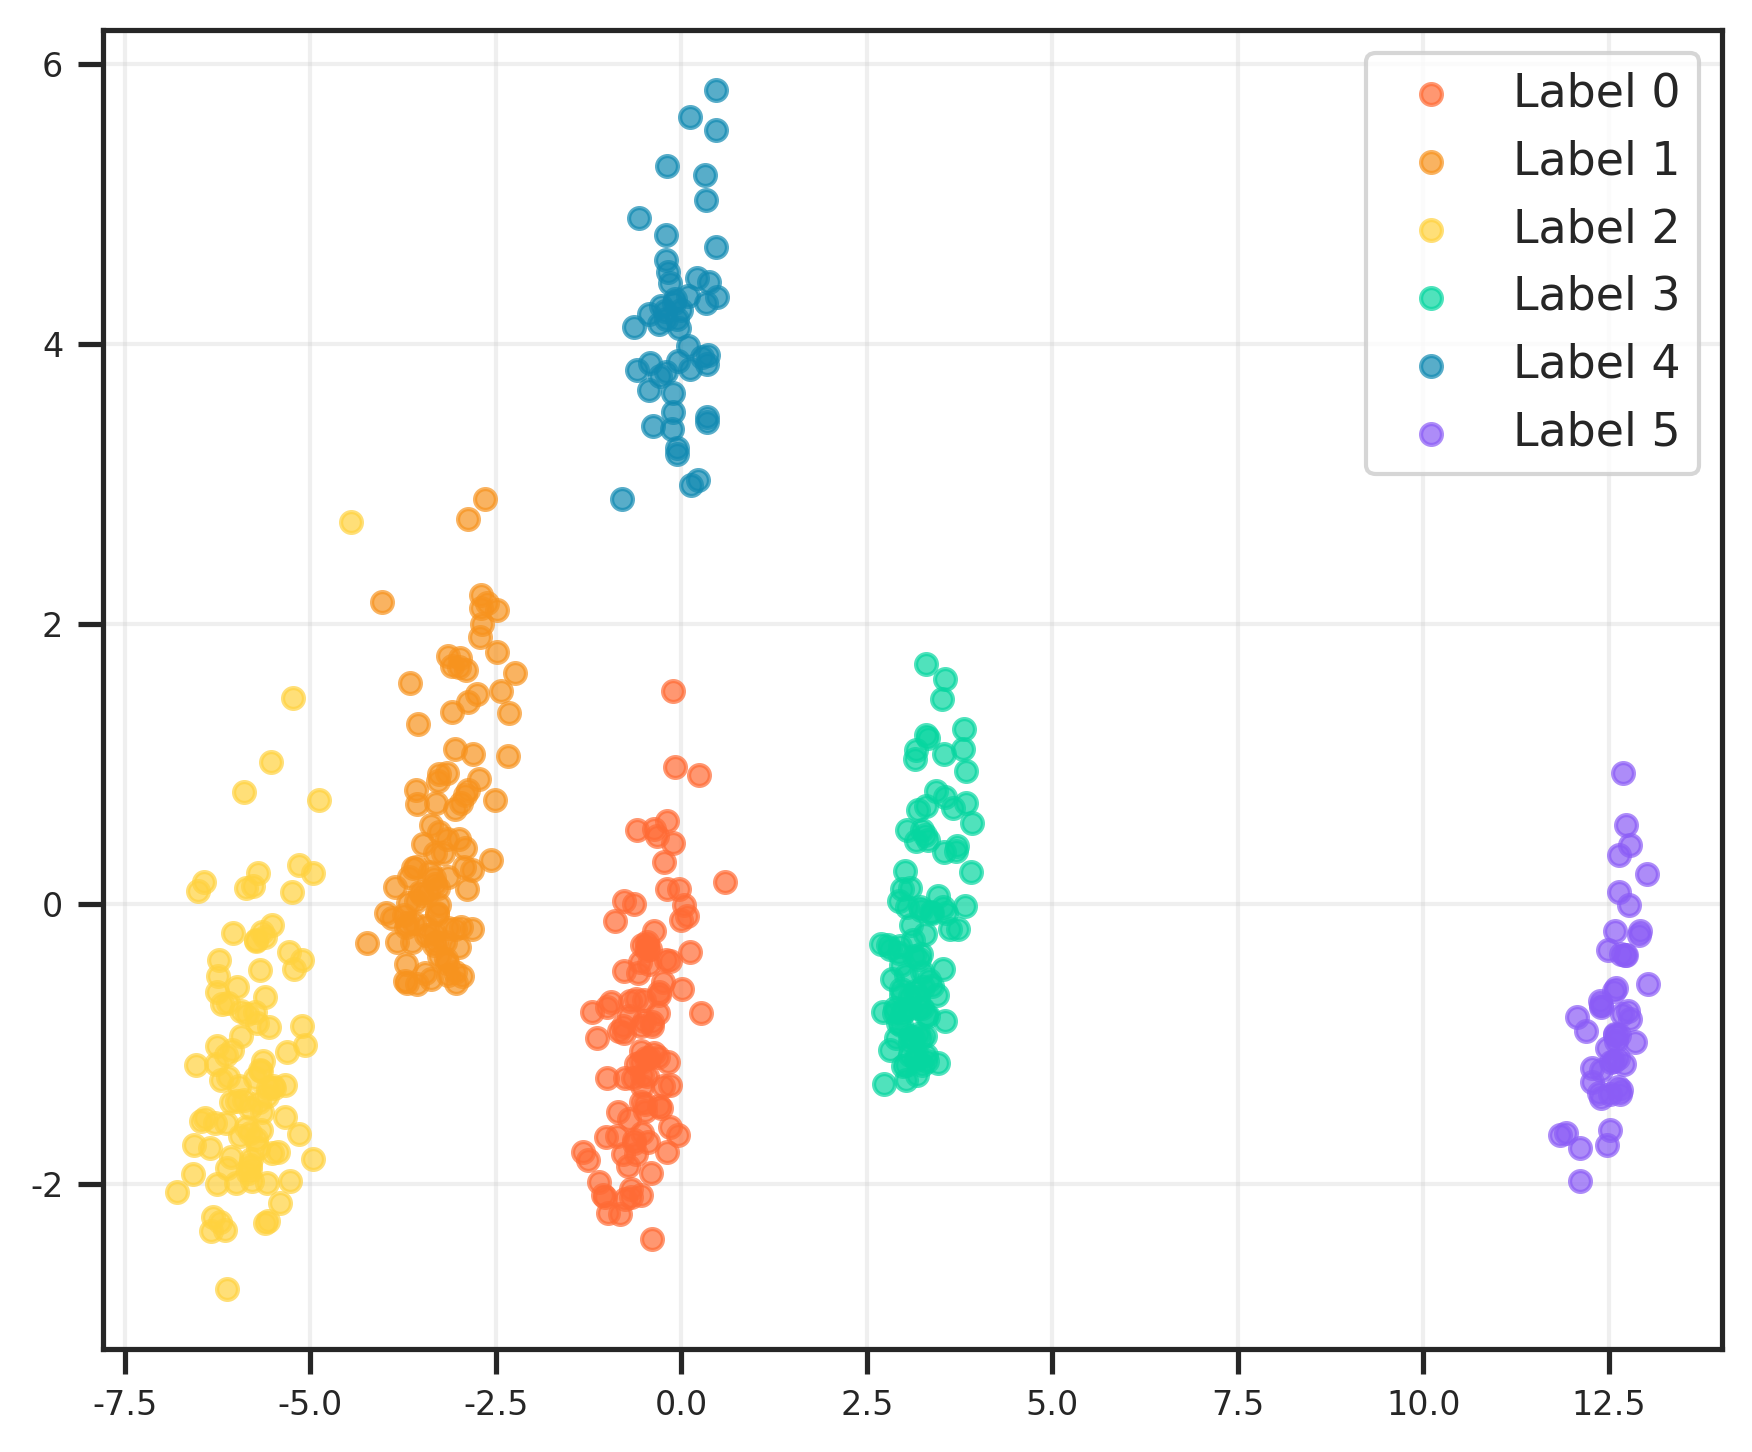

/tmp/ipykernel_17/1453065100.py:572: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


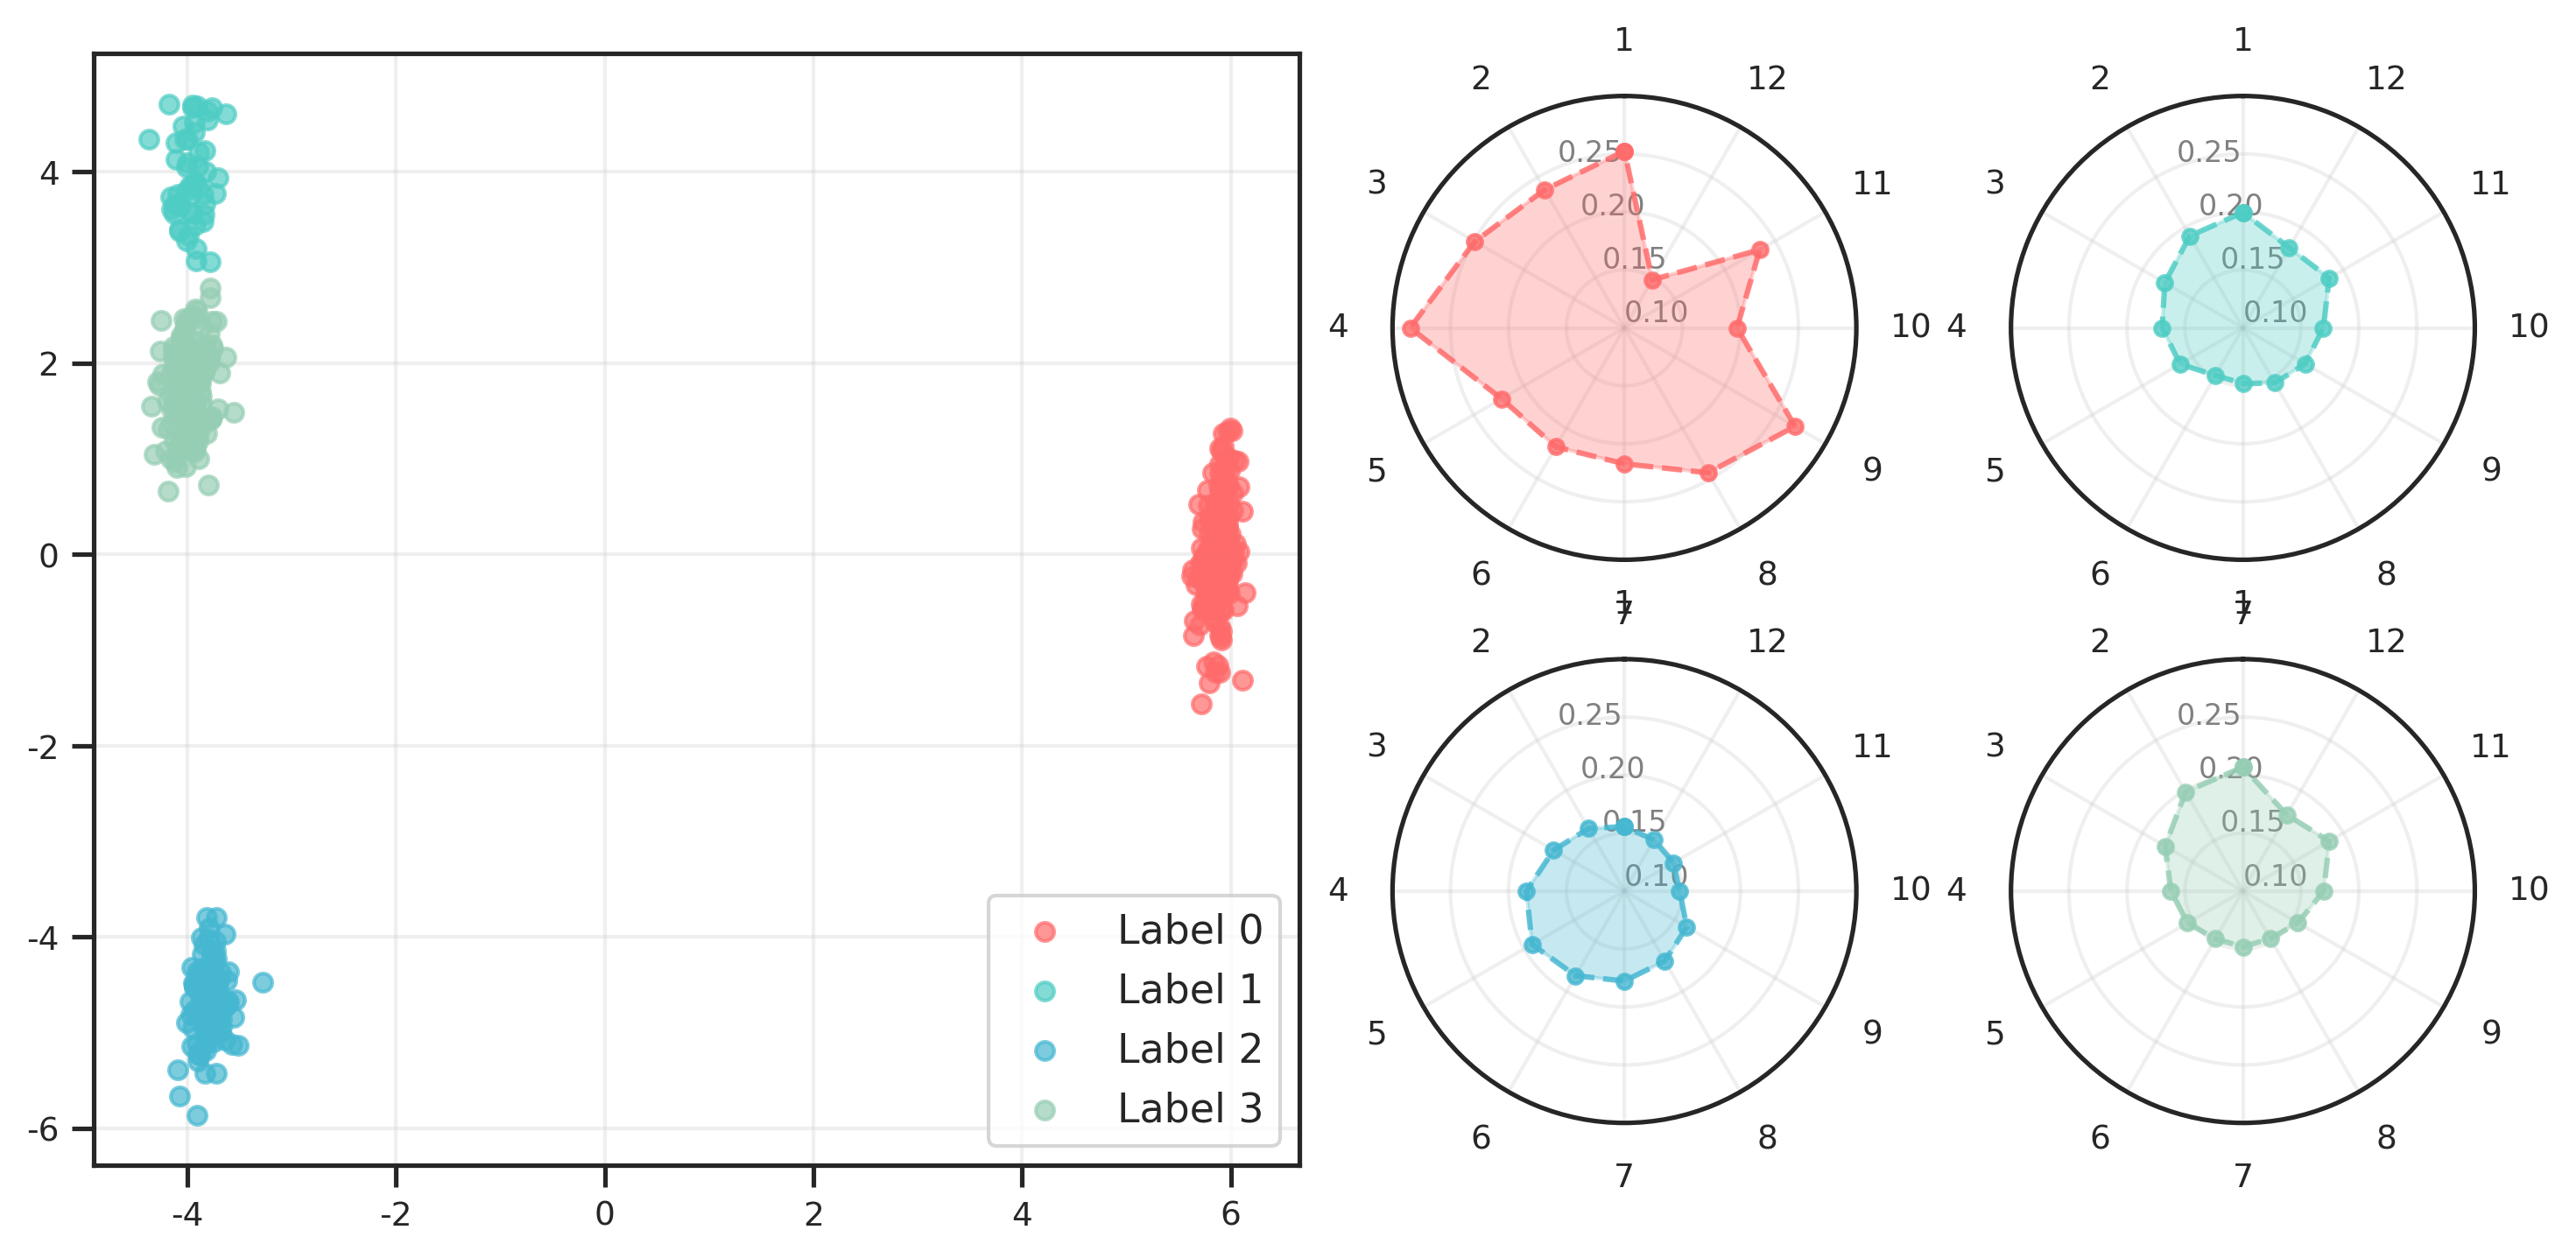

/tmp/ipykernel_17/1453065100.py:635: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


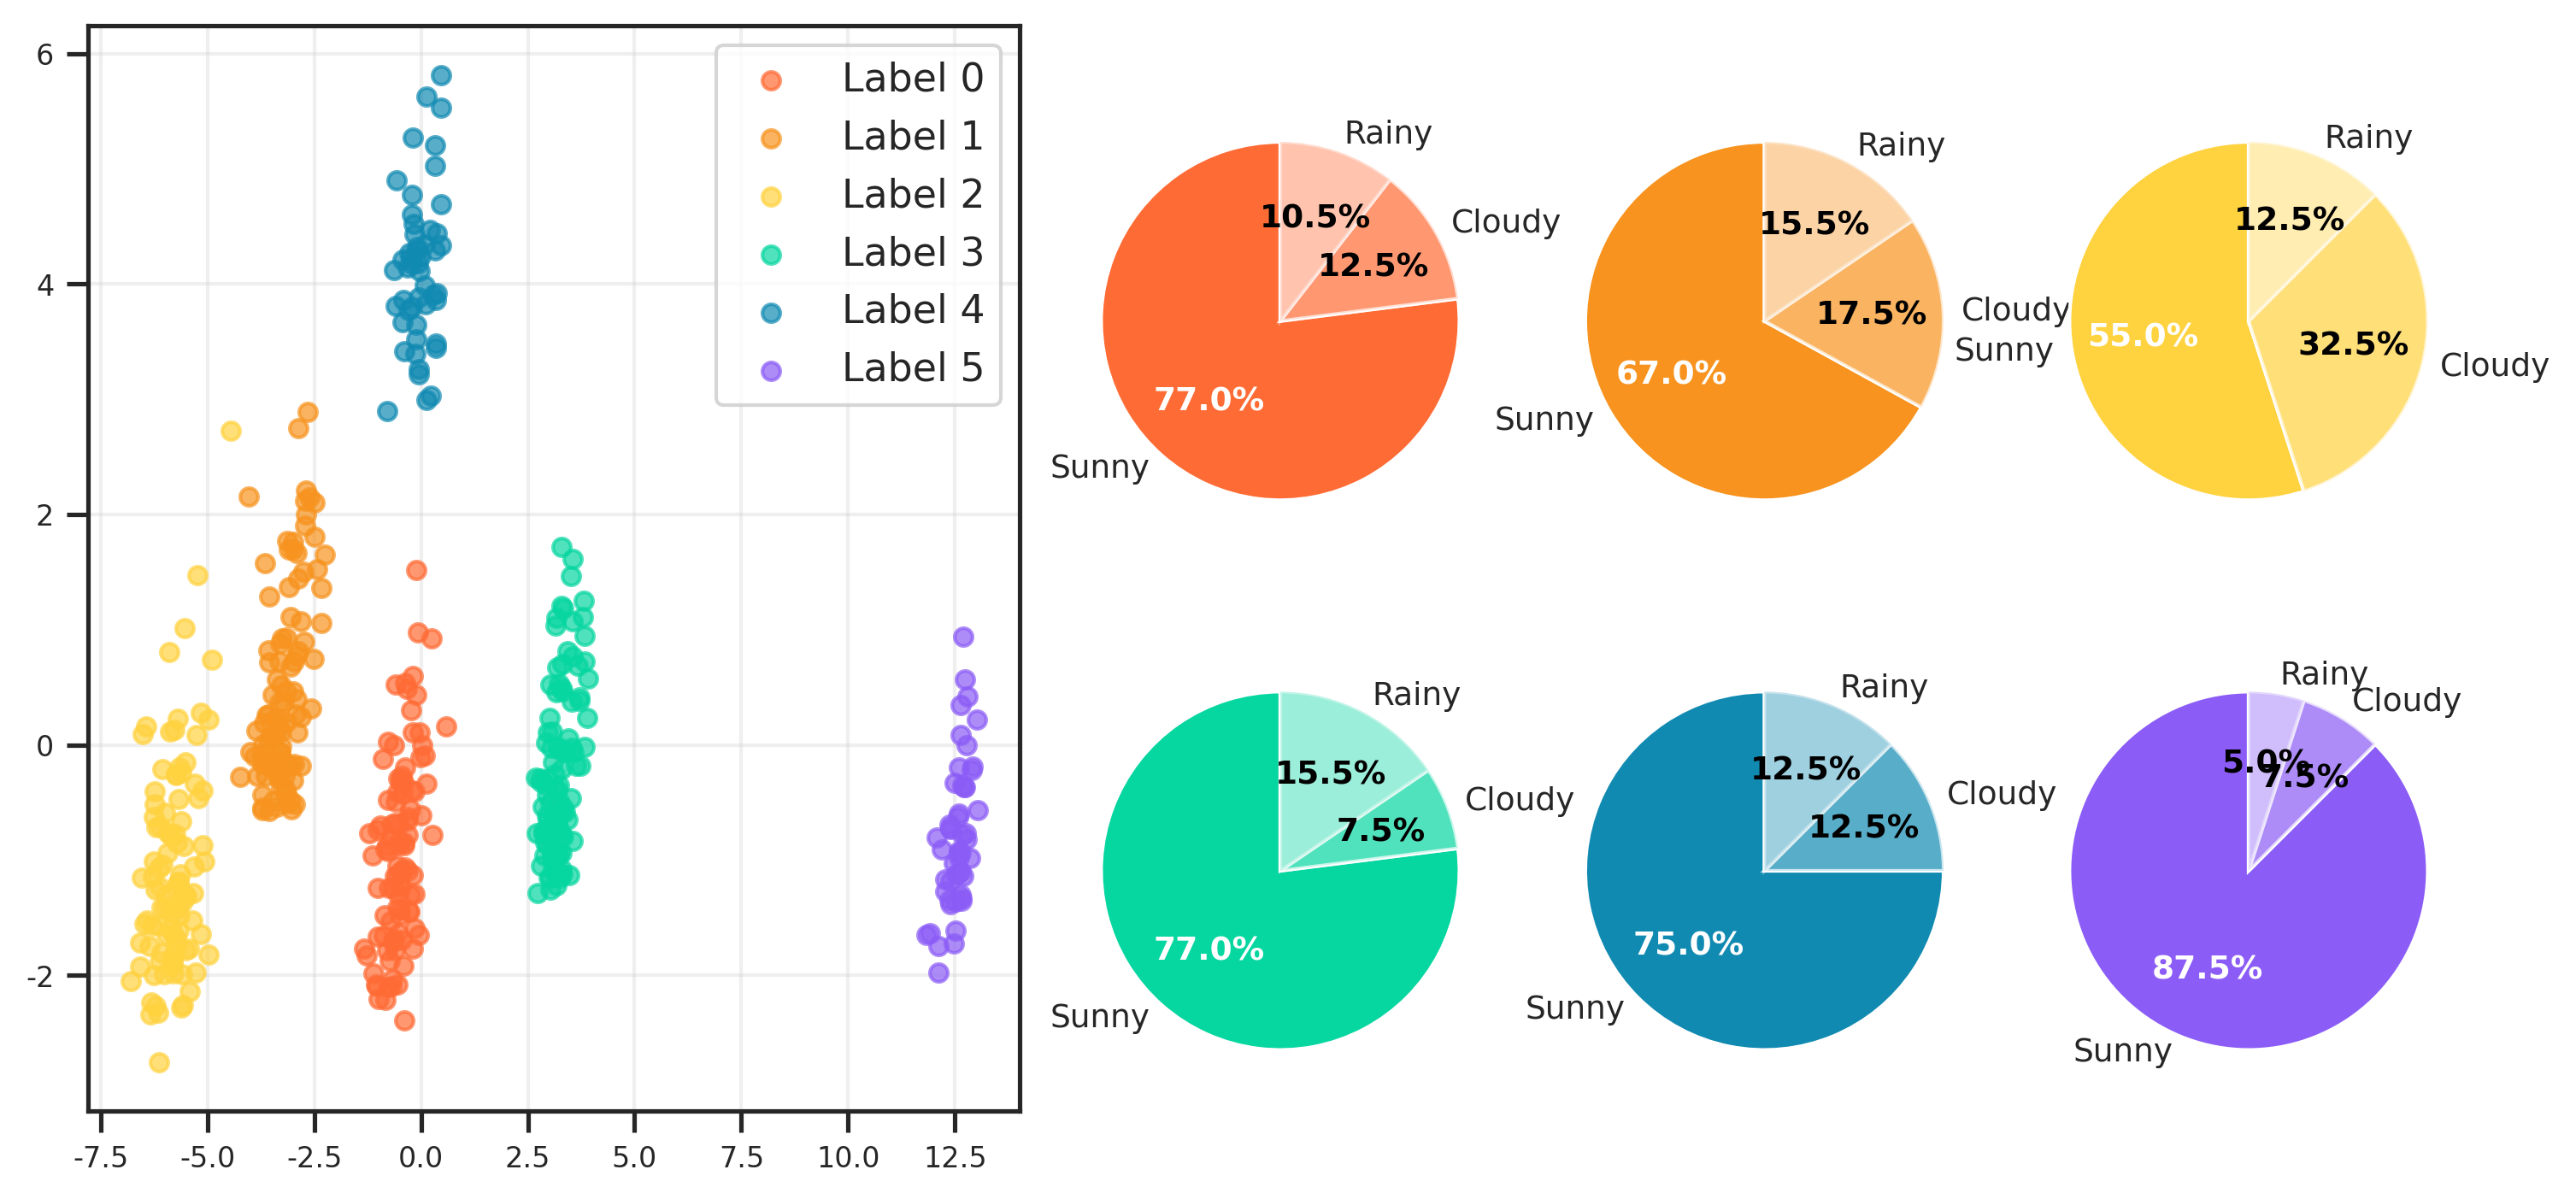

/tmp/ipykernel_17/1453065100.py:691: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


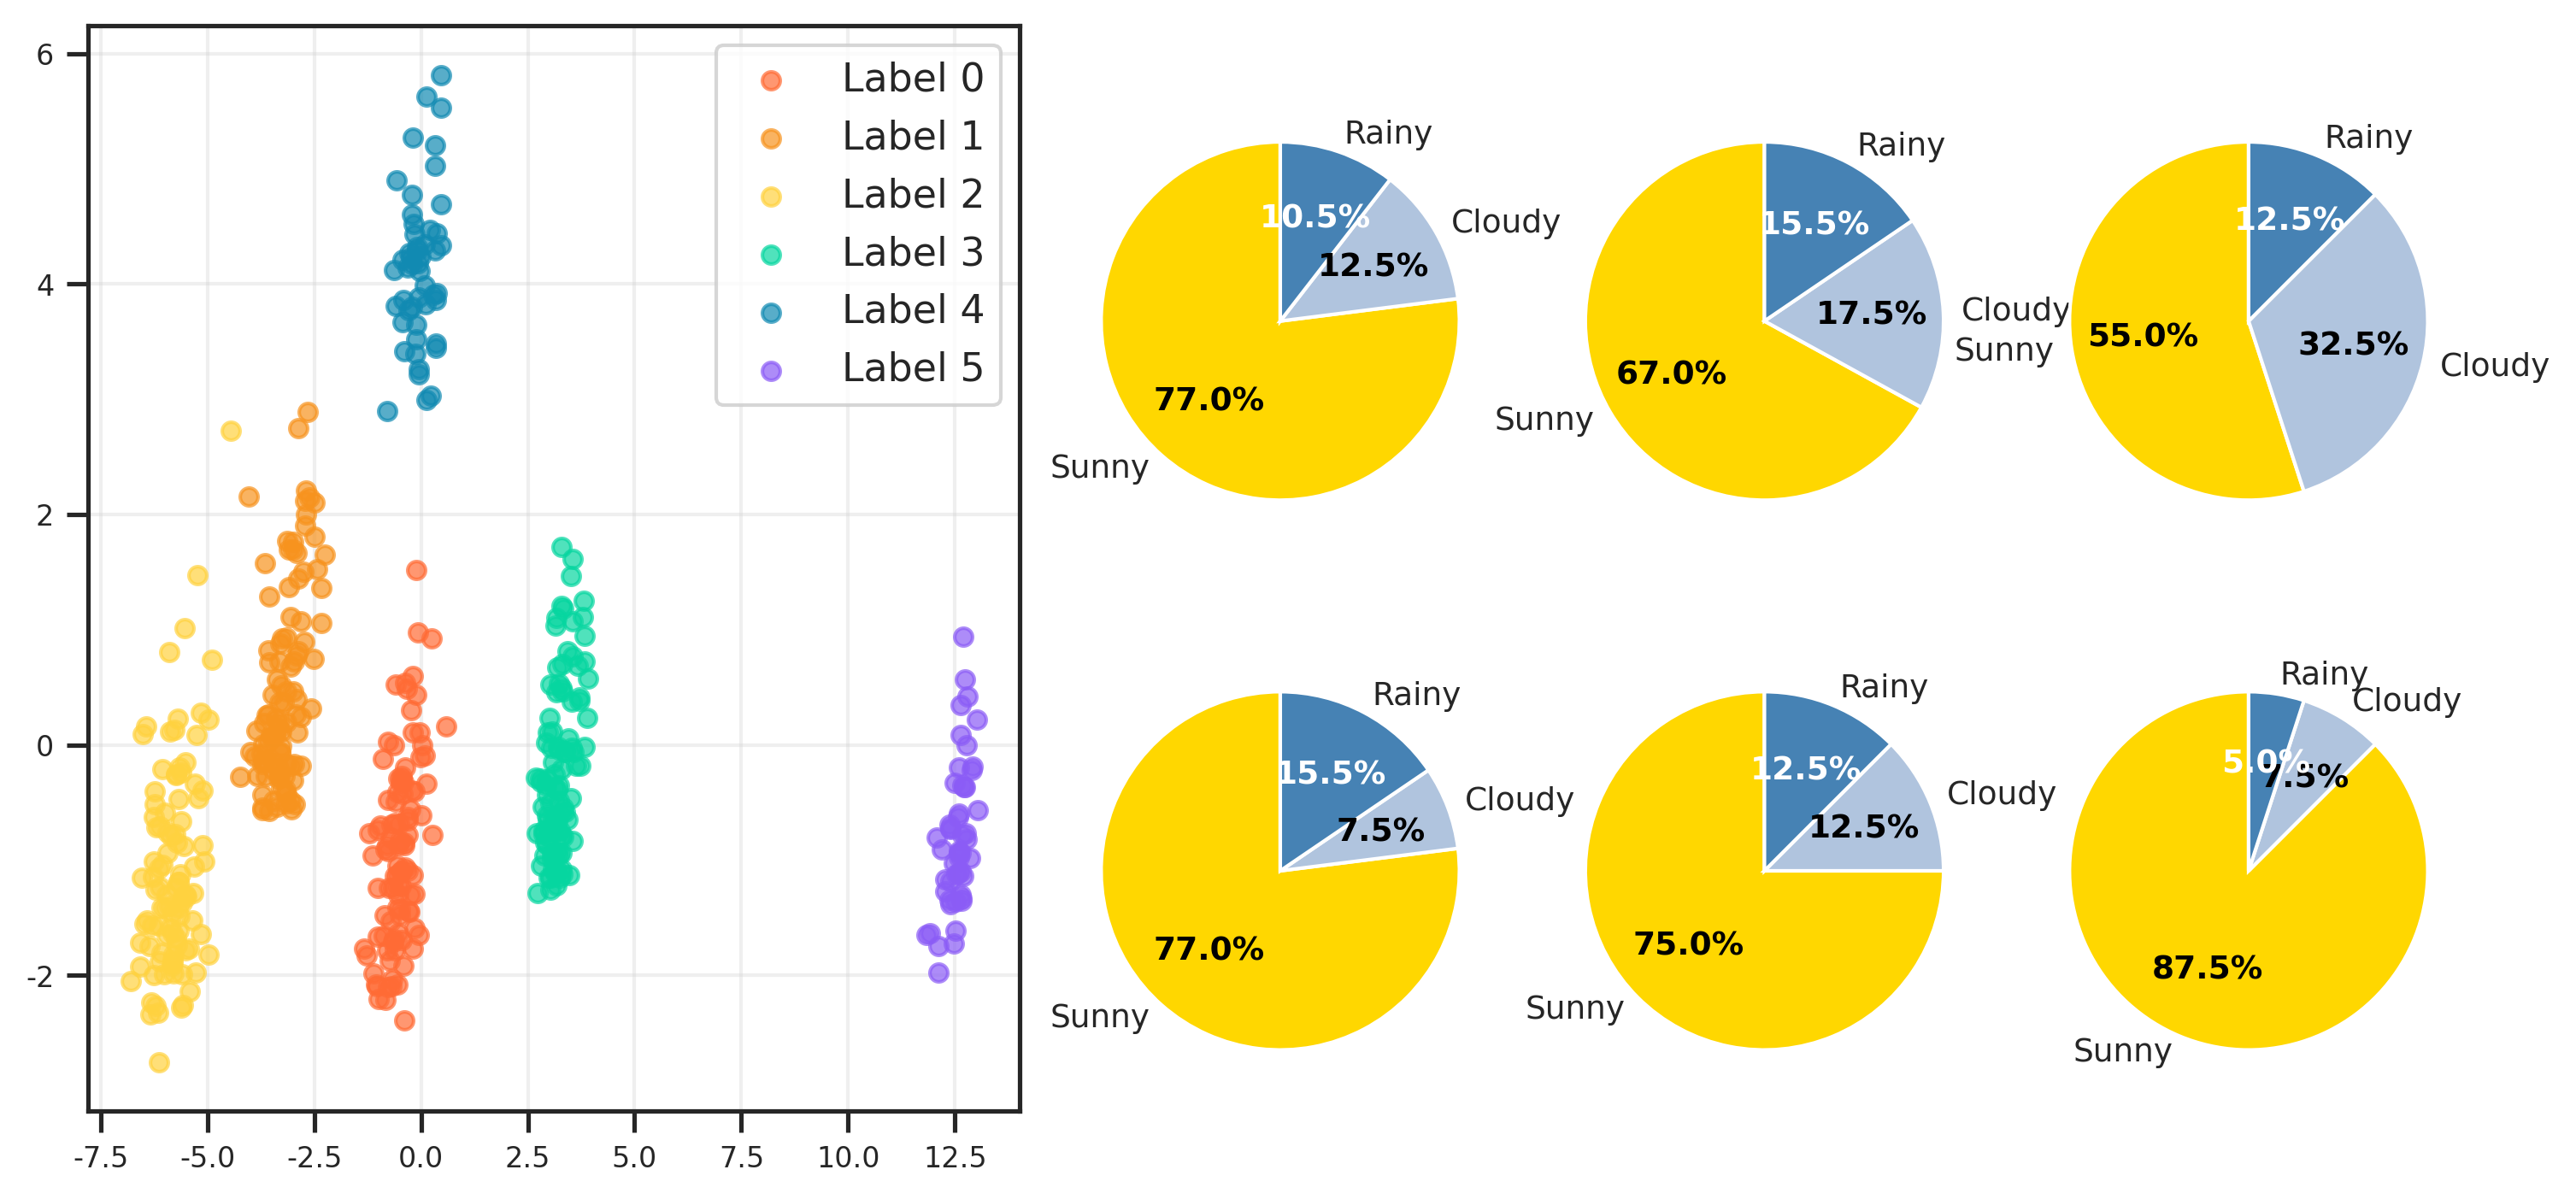

In [1]:
!pip install scienceplots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
from typing import List
import scienceplots
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family']='Times New Roman'
plt.rcParams['axes.unicode_minus']= False
sns.set(style='ticks')
plt.style.use(sorted(plt.style.available)[31])

wind_series_500 = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind.csv")
power_df = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV.csv")

def split_wind_series(wind_series_500: pd.DataFrame) -> List[pd.DataFrame]:
    time_series_list = []
    timestamp_col = wind_series_500.iloc[:, 0]
    wind_power_cols = wind_series_500.columns[1:]
    for i, col_name in enumerate(wind_power_cols, 1):
        single_series_df = pd.DataFrame({
            'timestamp': timestamp_col,
            f'wind_power_{i}': wind_series_500[col_name]
        })
        time_series_list.append(single_series_df)
    
    return time_series_list

def split_PV_series(power_df: pd.DataFrame) -> List[pd.DataFrame]:
    time_series_list = []
    timestamp_col = power_df.iloc[:, 0]
    PV_power_cols = power_df.columns[1:]
    for i, col_name in enumerate(PV_power_cols, 1):
        single_series_df = pd.DataFrame({
            'timestamp': timestamp_col,
            f'PV_power_{i}': power_df[col_name]
        })
        time_series_list.append(single_series_df)
    
    return time_series_list

time_series_list = split_wind_series(wind_series_500)
time_series_list_PV = split_PV_series(power_df)

def calculate_monthly_baselines(time_series_list: List[pd.DataFrame]) -> List[np.ndarray]:
    class_ranges = [
        (0, 200),
        (200, 350),
        (350, 450),
        (450, 500)
    ]
    monthly_baselines = []
    
    for class_idx, (start_idx, end_idx) in enumerate(class_ranges):
        class_monthly_data = {month: [] for month in range(1, 13)}
        for series_idx in range(start_idx, end_idx):
            df = time_series_list[series_idx].copy()
            if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
                df['timestamp'] = pd.to_datetime(df['timestamp'])

            df['month'] = df['timestamp'].dt.month
            power_col = df.columns[1]

            monthly_avg = df.groupby('month')[power_col].mean()

            for month in range(1, 13):
                if month in monthly_avg.index:
                    class_monthly_data[month].append(monthly_avg[month])

        class_baseline = []
        for month in range(1, 13):
            if class_monthly_data[month]:
                month_baseline = np.mean(class_monthly_data[month])
            else:
                month_baseline = 0.0
            class_baseline.append(month_baseline)
        
        monthly_baselines.append(np.array(class_baseline))

    return monthly_baselines

monthly_baselines = calculate_monthly_baselines(time_series_list)

def extract_seasonal_features(time_series_list):
        features_list = []
        
        for i, df in enumerate(time_series_list):
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            power_col = [col for col in df.columns if 'wind_power' in col][0]
            powers = df[power_col].values

            mean_power = np.mean(powers)
            std_power = np.std(powers)
            var_power = np.var(powers)
            max_power = np.max(powers)
            min_power = np.min(powers)
            cv = std_power / mean_power if mean_power > 0 else 0

            df['month'] = df['timestamp'].dt.month
            df['hour'] = df['timestamp'].dt.hour
            df['day_of_year'] = df['timestamp'].dt.dayofyear

            def get_season(month):
                if month in [3, 4, 5]:
                    return 'spring'
                elif month in [6, 7, 8]:
                    return 'summer'
                elif month in [9, 10, 11]:
                    return 'autumn'
                else:  # 12, 1, 2
                    return 'winter'
            
            df['season'] = df['month'].apply(get_season)

            seasonal_avg = df.groupby('season')[power_col].mean()
            spring_power = seasonal_avg.get('spring', 0)
            summer_power = seasonal_avg.get('summer', 0)
            autumn_power = seasonal_avg.get('autumn', 0)
            winter_power = seasonal_avg.get('winter', 0)

            monthly_avg = df.groupby('month')[power_col].mean()

            winter_summer_ratio = winter_power / summer_power if summer_power > 0 else 0
            spring_autumn_avg = (spring_power + autumn_power) / 2
            summer_winter_avg = (summer_power + winter_power) / 2

            seasonal_powers = [spring_power, summer_power, autumn_power, winter_power]
            seasonal_std = np.std(seasonal_powers)
            seasonal_cv = seasonal_std / np.mean(seasonal_powers) if np.mean(seasonal_powers) > 0 else 0
            seasonal_range = max(seasonal_powers) - min(seasonal_powers)

            monsoon_pattern = (spring_autumn_avg > summer_power) and (summer_power > winter_power)

            oceanic_pattern = winter_power > summer_power

            polar_pattern = winter_power > 1.5 * summer_power if summer_power > 0 else False

            trade_wind_pattern = seasonal_cv < 0.3

            monthly_std = np.std(list(monthly_avg.values))
            monthly_cv = monthly_std / np.mean(list(monthly_avg.values)) if np.mean(list(monthly_avg.values)) > 0 else 0

            max_season_power = max(seasonal_powers)
            min_season_power = min(seasonal_powers)
            seasonal_amplitude = max_season_power - min_season_power

            winter_spring_ratio = winter_power / spring_power if spring_power > 0 else 0
            autumn_summer_ratio = autumn_power / summer_power if summer_power > 0 else 0

            def autocorrelation(x, lag):
                if lag >= len(x):
                    return 0
                n = len(x) - lag
                if n <= 1:
                    return 0
                x_mean = np.mean(x)
                numerator = np.sum((x[:n] - x_mean) * (x[lag:lag+n] - x_mean))
                denominator = np.sum((x - x_mean) ** 2)
                return numerator / denominator if denominator > 0 else 0
            
            autocorr_1h = autocorrelation(powers, 4)
            autocorr_1d = autocorrelation(powers, 96)
            autocorr_1w = autocorrelation(powers, 672)

            hourly_avg = df.groupby('hour')[power_col].mean()
            hour_6 = hourly_avg.get(6, 0)
            hour_12 = hourly_avg.get(12, 0)
            hour_18 = hourly_avg.get(18, 0)
            hour_0 = hourly_avg.get(0, 0)

            features = [
                mean_power, std_power, var_power, max_power, min_power, cv,

                spring_power, summer_power, autumn_power, winter_power,
                winter_summer_ratio, spring_autumn_avg, summer_winter_avg, seasonal_amplitude,

                seasonal_std, seasonal_cv, seasonal_range, monthly_cv,

                float(monsoon_pattern), float(oceanic_pattern), 
                float(polar_pattern), float(trade_wind_pattern),

                winter_spring_ratio, autumn_summer_ratio,

                autocorr_1h, autocorr_1d, autocorr_1w,

                hour_6, hour_12, hour_18, hour_0,

                monthly_avg.get(1, 0),
                monthly_avg.get(4, 0),
                monthly_avg.get(7, 0),
                monthly_avg.get(10, 0),
            ]
            features_list.append(features)
        
        return np.array(features_list)

def extract_seasonal_features_PV(time_series_list):
        features_list = []
        
        for i, df in enumerate(time_series_list):
            df['timestamp'] = pd.to_datetime(df['timestamp'])

            power_col = [col for col in df.columns if 'PV_power' in col or 'solar_power' in col][0]
            powers = df[power_col].values

            mean_power = np.mean(powers)
            std_power = np.std(powers)
            var_power = np.var(powers)
            max_power = np.max(powers)
            min_power = np.min(powers)
            cv = std_power / mean_power if mean_power > 0 else 0

            df['month'] = df['timestamp'].dt.month
            df['hour'] = df['timestamp'].dt.hour
            df['day_of_year'] = df['timestamp'].dt.dayofyear

            daytime_mask = (df['hour'] >= 6) & (df['hour'] <= 18)
            daytime_df = df[daytime_mask].copy()
            daytime_powers = daytime_df[power_col].values

            daytime_mean = np.mean(daytime_powers) if len(daytime_powers) > 0 else 0
            daytime_std = np.std(daytime_powers) if len(daytime_powers) > 0 else 0
            daytime_max = np.max(daytime_powers) if len(daytime_powers) > 0 else 0

            def get_season(month):
                if month in [3, 4, 5]:
                    return 'spring'
                elif month in [6, 7, 8]:
                    return 'summer'
                elif month in [9, 10, 11]:
                    return 'autumn'
                else:  # 12, 1, 2
                    return 'winter'
            
            df['season'] = df['month'].apply(get_season)

            daytime_df['season'] = daytime_df['month'].apply(get_season)
            seasonal_avg = daytime_df.groupby('season')[power_col].mean()
            seasonal_std = daytime_df.groupby('season')[power_col].std()
            
            spring_power = seasonal_avg.get('spring', 0)
            summer_power = seasonal_avg.get('summer', 0)
            autumn_power = seasonal_avg.get('autumn', 0)
            winter_power = seasonal_avg.get('winter', 0)
            
            spring_std = seasonal_std.get('spring', 0)
            summer_std = seasonal_std.get('summer', 0)
            autumn_std = seasonal_std.get('autumn', 0)
            winter_std = seasonal_std.get('winter', 0)

            def classify_weather_condition(power, max_power):
                if max_power == 0:
                    return 'night'
                ratio = power / max_power
                if ratio > 0.7:
                    return 'sunny'
                elif ratio > 0.3:
                    return 'cloudy'  
                else:
                    return 'rainy_overcast'

            weather_conditions = []
            for _, row in daytime_df.iterrows():
                condition = classify_weather_condition(row[power_col], daytime_max)
                weather_conditions.append(condition)

            weather_counts = pd.Series(weather_conditions).value_counts()
            total_daytime = len(weather_conditions)
            
            sunny_ratio = weather_counts.get('sunny', 0) / total_daytime if total_daytime > 0 else 0
            cloudy_ratio = weather_counts.get('cloudy', 0) / total_daytime if total_daytime > 0 else 0
            rainy_ratio = weather_counts.get('rainy_overcast', 0) / total_daytime if total_daytime > 0 else 0

            summer_mask = daytime_df['month'].isin([6, 7, 8])
            if summer_mask.any():
                summer_weather = []
                for _, row in daytime_df[summer_mask].iterrows():
                    condition = classify_weather_condition(row[power_col], daytime_max)
                    summer_weather.append(condition)
                summer_weather_counts = pd.Series(summer_weather).value_counts()
                summer_total = len(summer_weather)
                summer_rainy_ratio = summer_weather_counts.get('rainy_overcast', 0) / summer_total if summer_total > 0 else 0
            else:
                summer_rainy_ratio = 0

            winter_mask = daytime_df['month'].isin([12, 1, 2])
            if winter_mask.any():
                winter_weather = []
                for _, row in daytime_df[winter_mask].iterrows():
                    condition = classify_weather_condition(row[power_col], daytime_max)
                    winter_weather.append(condition)
                winter_weather_counts = pd.Series(winter_weather).value_counts()
                winter_total = len(winter_weather)
                winter_sunny_ratio = winter_weather_counts.get('sunny', 0) / winter_total if winter_total > 0 else 0
                winter_rainy_ratio = winter_weather_counts.get('rainy_overcast', 0) / winter_total if winter_total > 0 else 0
            else:
                winter_sunny_ratio = 0
                winter_rainy_ratio = 0

            power_diff = np.diff(daytime_powers)
            power_volatility = np.std(power_diff) if len(power_diff) > 0 else 0

            high_freq_changes = np.sum(np.abs(power_diff) > 0.1 * daytime_max) if len(power_diff) > 0 else 0
            cloud_fluctuation_ratio = high_freq_changes / len(power_diff) if len(power_diff) > 0 else 0

            monthly_avg = daytime_df.groupby('month')[power_col].mean()
            monthly_std = daytime_df.groupby('month')[power_col].std()

            jan_power = monthly_avg.get(1, 0)
            apr_power = monthly_avg.get(4, 0)
            jul_power = monthly_avg.get(7, 0)
            oct_power = monthly_avg.get(10, 0)

            hourly_avg = daytime_df.groupby('hour')[power_col].mean()
            morning_power = np.mean([hourly_avg.get(h, 0) for h in [7, 8, 9]])
            noon_power = np.mean([hourly_avg.get(h, 0) for h in [11, 12, 13]])
            evening_power = np.mean([hourly_avg.get(h, 0) for h in [16, 17, 18]])

            daily_amplitude = noon_power - morning_power if noon_power > morning_power else 0

            tropical_monsoon_pattern = (sunny_ratio > 0.7) and (summer_rainy_ratio > rainy_ratio + 0.05)

            subtropical_monsoon_pattern = (0.6 < sunny_ratio < 0.75) and (max(seasonal_avg) - min(seasonal_avg) > 0.2 * daytime_mean)

            temperate_monsoon_pattern = (0.5 < sunny_ratio < 0.65) and (winter_rainy_ratio < 0.1)

            continental_pattern = (sunny_ratio > 0.7) and (cloudy_ratio < 0.15) and (winter_rainy_ratio < 0.1)

            plateau_pattern = (sunny_ratio > 0.7) and (cloudy_ratio < 0.15) and (cloud_fluctuation_ratio < 0.05)

            arid_pattern = (sunny_ratio > 0.8) and (cloudy_ratio < 0.1) and (rainy_ratio < 0.1)

            consecutive_sunny_days = 0
            max_consecutive_sunny = 0
            daily_avg = daytime_df.groupby(daytime_df['timestamp'].dt.date)[power_col].mean()
            
            for power in daily_avg.values:
                if power > 0.7 * daytime_max:
                    consecutive_sunny_days += 1
                    max_consecutive_sunny = max(max_consecutive_sunny, consecutive_sunny_days)
                else:
                    consecutive_sunny_days = 0

            seasonal_cv = {}
            for season in ['spring', 'summer', 'autumn', 'winter']:
                season_data = seasonal_avg.get(season, 0)
                season_std_val = seasonal_std.get(season, 0)
                seasonal_cv[season] = season_std_val / season_data if season_data > 0 else 0

            features = [
                mean_power, std_power, var_power, max_power, min_power, cv,

                daytime_mean, daytime_std, daytime_max,

                spring_power, summer_power, autumn_power, winter_power,
                spring_std, summer_std, autumn_std, winter_std,

                sunny_ratio, cloudy_ratio, rainy_ratio,

                summer_rainy_ratio, winter_sunny_ratio, winter_rainy_ratio,

                power_volatility, cloud_fluctuation_ratio,

                morning_power, noon_power, evening_power, daily_amplitude,

                jan_power, apr_power, jul_power, oct_power,

                float(tropical_monsoon_pattern),
                float(subtropical_monsoon_pattern),
                float(temperate_monsoon_pattern),
                float(continental_pattern),
                float(plateau_pattern),
                float(arid_pattern),

                max_consecutive_sunny,
                seasonal_cv.get('summer', 0),
                seasonal_cv.get('winter', 0)
            ]
            
            features_list.append(features)
        
        return np.array(features_list)

def dimension_reduction(features, method='pca', n_components=2):
        features_scaled = StandardScaler().fit_transform(features)
        
        if method.lower() == 'pca':
            reduced_data = PCA(n_components=n_components, random_state=42).fit_transform(features_scaled)
            
        elif method.lower() == 'tsne':
            reduced_data = TSNE(n_components=n_components, random_state=42, perplexity=30, n_iter=1000).fit_transform(features_scaled)
            
        else:
            raise ValueError("method must be 'pca' or 'tsne'")
        
        return reduced_data

def perform_clustering(data, n_clusters=4, method='kmeans'):
        if method.lower() == 'kmeans':
            cluster_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(data)
            
            # 计算轮廓系数
            silhouette_avg = silhouette_score(data, cluster_labels)
            
        else:
            raise ValueError("only k-means is available")
        
        return cluster_labels

def plot_clustering_results(data, true_labels=None, cluster_labels=None, save_path=None):
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        if true_labels is not None:
            for i, label in enumerate(np.unique(true_labels)):
                mask = true_labels == label
                axes[0].scatter(data[mask, 0], data[mask, 1], 
                              c=colors[i], alpha=0.7, s=20)
            axes[0].tick_params(axis='both', which='major', labelsize=8)
            axes[0].grid(True, alpha=0.3)

        if cluster_labels is not None:
            for i, label in enumerate(np.unique(cluster_labels)):
                mask = cluster_labels == label
                axes[1].scatter(data[mask, 0], data[mask, 1], 
                              c=colors[i], alpha=0.7, s=20)
            axes[1].tick_params(axis='both', which='major', labelsize=8)
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()

def plot_clustering_results_kmeans(data, cluster_labels=None):
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    fig, axes = plt.subplots(figsize=(6, 5))

    if cluster_labels is not None:
        for i, label in enumerate(np.unique(cluster_labels)):
            mask = cluster_labels == label
            axes.scatter(data[mask, 0], data[mask, 1], 
                          c=colors[i], alpha=0.7, s=20, 
                          label=f'Label {label}')
        axes.tick_params(axis='both', which='major', labelsize=8)
        axes.grid(True, alpha=0.3)
        axes.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

def plot_clustering_results_PV_kmeans(data, cluster_labels=None):
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    
    fig, axes = plt.subplots(figsize=(6, 5))

    if cluster_labels is not None:
        for i, label in enumerate(np.unique(cluster_labels)):
            mask = cluster_labels == label
            axes.scatter(data[mask, 0], data[mask, 1], 
                          c=colors[i], alpha=0.7, s=20, 
                          label=f'Label {label}')
        axes.tick_params(axis='both', which='major', labelsize=8)
        axes.grid(True, alpha=0.3)
        axes.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

def plot_clustering_results_PV_true(data, true_labels=None):
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    
    fig, axes = plt.subplots(figsize=(6, 5))

    for i, label in enumerate(np.unique(true_labels)):
        mask = true_labels == label
        axes.scatter(data[mask, 0], data[mask, 1], 
                      c=colors[i], alpha=0.7, s=25, 
                      label=f'Label {label}')
    axes.tick_params(axis='both', which='major', labelsize=8)
    axes.grid(True, alpha=0.3)
    axes.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

features = extract_seasonal_features(time_series_list)
reduced_data = dimension_reduction(features, method='pca')
cluster_labels = perform_clustering(reduced_data, n_clusters=4)
true_labels = np.array([0]*200 + [1]*150 + [2]*100 + [3]*50)
plot_clustering_results(
        reduced_data, 
        true_labels=true_labels, 
        cluster_labels=cluster_labels
    )
plot_clustering_results_kmeans(
        reduced_data, 
        cluster_labels=cluster_labels
    )

features_PV = extract_seasonal_features_PV(time_series_list_PV)
reduced_data_PV = dimension_reduction(features_PV, method='pca')
cluster_labels_PV = perform_clustering(reduced_data, n_clusters=6)
pv_labels = np.array([0]*100 + [1]*100 + [2]*100 + [3]*100 + [4]*50 + [5]*50)
plot_clustering_results_PV_kmeans(
        reduced_data_PV, 
        cluster_labels=cluster_labels_PV
    )
plot_clustering_results_PV_true(reduced_data_PV, true_labels=pv_labels)

def plot_integrated_clustering_and_baselines(reduced_data, cluster_labels, monthly_baselines):
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    fig = plt.figure(figsize=(12, 5.5))
    grid = plt.GridSpec(40, 40, wspace=1, hspace=1)

    ax1 = fig.add_subplot(grid[:, :20])
    ax2 = fig.add_subplot(grid[1:19, 21:29], projection='polar')
    ax3 = fig.add_subplot(grid[1:19, 31:39], projection='polar')
    ax4 = fig.add_subplot(grid[21:39, 21:29], projection='polar')
    ax5 = fig.add_subplot(grid[21:39, 31:39], projection='polar')

    for i, label in enumerate(np.unique(cluster_labels)):
        mask = cluster_labels == label
        ax1.scatter(reduced_data[mask, 0], reduced_data[mask, 1], 
                   c=colors[i], alpha=0.7, s=25, label=f'Label {label}')
    ax1.tick_params(axis='both', which='major', labelsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right')

    polar_axes = [ax2, ax3, ax4, ax5]

    angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))
    
    for i, ax in enumerate(polar_axes):
        baseline_data = monthly_baselines[i]
        baseline_data_closed = np.concatenate((baseline_data, [baseline_data[0]]))

        ax.plot(angles, baseline_data_closed, 'o--', 
               color=colors[i], alpha=0.8, linewidth=1.5, markersize=4)
        ax.fill(angles, baseline_data_closed, 
               color=colors[i], alpha=0.3)

        ax.set_ylim(0.1, 0.3)
        ax.set_yticks(np.arange(0.1, 0.3, 0.05))
        ax.set_yticklabels([f'{y:.2f}' for y in np.arange(0.1, 0.3, 0.05)], 
                          fontsize=8, color='gray')

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([str(i+1) for i in range(12)], fontsize=9)
        ax.set_theta_zero_location('N')
        ax.tick_params(pad=2)

        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
plot_integrated_clustering_and_baselines(reduced_data, cluster_labels, monthly_baselines)

def plot_solar_clustering_and_weather(data, true_labels):
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    weather_colors = ['#FFD700', '#B0C4DE', '#4682B4']
    weather_labels = ['Sunny', 'Cloudy', 'Rainy']
    weather_patterns = ['////', '....', 'xxxx']

    weather_data = {
        0: {'sunny': 0.77, 'cloudy': 0.125, 'rainy': 0.105},
        1: {'sunny': 0.67, 'cloudy': 0.175, 'rainy': 0.155},
        2: {'sunny': 0.55, 'cloudy': 0.325, 'rainy': 0.125},
        3: {'sunny': 0.77, 'cloudy': 0.075, 'rainy': 0.155},
        4: {'sunny': 0.75, 'cloudy': 0.125, 'rainy': 0.125},
        5: {'sunny': 0.875, 'cloudy': 0.075, 'rainy': 0.05}
    }

    fig = plt.figure(figsize=(12, 5.5))
    grid = plt.GridSpec(40, 40, wspace=1.5, hspace=1) 

    ax1 = fig.add_subplot(grid[:, :16])
    ax2 = fig.add_subplot(grid[2:20, 16:24])
    ax3 = fig.add_subplot(grid[2:20, 24:32]) 
    ax4 = fig.add_subplot(grid[2:20, 32:])
    ax5 = fig.add_subplot(grid[22:40, 16:24])
    ax6 = fig.add_subplot(grid[22:40, 24:32]) 
    ax7 = fig.add_subplot(grid[22:40, 32:])

    for i, label in enumerate(np.unique(true_labels)):
        mask = true_labels == label
        ax1.scatter(data[mask, 0], data[mask, 1], 
                   c=colors[i], alpha=0.7, s=25, 
                   label=f'Label {label}')
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    pie_axes = [ax2, ax3, ax4, ax5, ax6, ax7]

    for i, ax in enumerate(pie_axes):
        if i < len(weather_data):
            data_dict = weather_data[i]
            values = [data_dict['sunny'], data_dict['cloudy'], data_dict['rainy']]

            pie_colors = [colors[i]] * 3
            alphas = [1.0, 0.7, 0.4]
            
            wedges, texts, autotexts = ax.pie(values, labels=weather_labels, 
                                             colors=pie_colors, autopct='%1.1f%%',
                                             startangle=90, textprops={'fontsize': 9})

            for j, wedge in enumerate(wedges):
                wedge.set_alpha(alphas[j])

            text_colors = ['white', 'black', 'black']
            for j, autotext in enumerate(autotexts):
                autotext.set_color(text_colors[j])
                autotext.set_fontweight('bold')
                autotext.set_fontsize(9)
    
    plt.tight_layout()
    plt.show()

plot_solar_clustering_and_weather(reduced_data_PV, pv_labels)

def plot_solar_clustering_and_weather_v2(data, true_labels):
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    weather_colors = ['#FFD700', '#B0C4DE', '#4682B4']
    weather_labels = ['Sunny', 'Cloudy', 'Rainy']

    weather_data = {
        0: {'sunny': 0.77, 'cloudy': 0.125, 'rainy': 0.105},
        1: {'sunny': 0.67, 'cloudy': 0.175, 'rainy': 0.155},
        2: {'sunny': 0.55, 'cloudy': 0.325, 'rainy': 0.125},
        3: {'sunny': 0.77, 'cloudy': 0.075, 'rainy': 0.155},
        4: {'sunny': 0.75, 'cloudy': 0.125, 'rainy': 0.125},
        5: {'sunny': 0.875, 'cloudy': 0.075, 'rainy': 0.05}
    }

    fig = plt.figure(figsize=(12, 5.5))
    grid = plt.GridSpec(40, 40, wspace=1.5, hspace=1) 

    ax1 = fig.add_subplot(grid[:, :16])
    ax2 = fig.add_subplot(grid[2:20, 16:24])
    ax3 = fig.add_subplot(grid[2:20, 24:32]) 
    ax4 = fig.add_subplot(grid[2:20, 32:])
    ax5 = fig.add_subplot(grid[22:40, 16:24])
    ax6 = fig.add_subplot(grid[22:40, 24:32]) 
    ax7 = fig.add_subplot(grid[22:40, 32:])

    for i, label in enumerate(np.unique(true_labels)):
        mask = true_labels == label
        ax1.scatter(data[mask, 0], data[mask, 1], 
                   c=colors[i], alpha=0.7, s=25, 
                   label=f'Label {label}')
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    pie_axes = [ax2, ax3, ax4, ax5, ax6, ax7]

    for i, ax in enumerate(pie_axes):
        if i < len(weather_data):
            data_dict = weather_data[i]
            values = [data_dict['sunny'], data_dict['cloudy'], data_dict['rainy']]
            
            wedges, texts, autotexts = ax.pie(values, labels=weather_labels, 
                                             colors=weather_colors, autopct='%1.1f%%',
                                             startangle=90, textprops={'fontsize': 9})

            text_colors = ['black', 'black', 'white']
            for j, autotext in enumerate(autotexts):
                autotext.set_color(text_colors[j])
                autotext.set_fontweight('bold')
                autotext.set_fontsize(9)
    
    plt.tight_layout()
    plt.show()

plot_solar_clustering_and_weather_v2(reduced_data_PV, pv_labels)